# **HW2 MLE and Naive Bayes**

1. **Chantouch Orungrote | 66340500011**
2. **Sasish Kaewsing | 66340500076**

---

## **Chapter 01**
### **1. Find the MLE od return rate**

From the MLE instruction, we know that $w_i\sim\mathcal{N}(0, \sigma^2)$, meaning the noise is **Guassian with mean $(μ)$ zero**.
So, we can find the mean of each $y_i$ by calculate the **Expected value $(E[X])$** in condition that we already observed the $y_0, y_1, y_2$ so they would be the constant instead of random variables.
And also the noise of each day $(w_i = x_i - \mu_i)$ will be like this below

$$
\begin{aligned}
y_2 &= \alpha y_1 + \delta x + w_2 
&\Rightarrow\quad 
\mu_2 &= E[y_2] = \alpha E[y_1] + \delta x 
&\Rightarrow\quad 
w_2 &= y_2 - (\alpha y_1 + \delta x) \\[6pt]

y_1 &= \alpha y_0 + \delta x + w_1 
&\Rightarrow\quad 
\mu_1 &= E[y_1] = \alpha E[y_0] + \delta x 
&\Rightarrow\quad 
w_1 &= y_1 - (\alpha y_0 + \delta x) \\[6pt]

y_0 &= \delta x + w_0 
&\Rightarrow\quad 
\mu_0 &= E[y_0] = \delta x 
&\Rightarrow\quad 
w_0 &= y_0 - \delta x
\end{aligned}
$$

Then, replace $x, \delta, μ$ in **the Normal distribution Probability Density Function**

$$
\begin{aligned}
y_0 &\sim \mathcal{N}(\delta x,\sigma^2) 
&\Rightarrow\quad 
p(y_0) &= \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{w_0^2}{2\sigma^2}\right) \\[6pt]

y_1 \mid y_0 &\sim \mathcal{N}(\alpha y_0+\delta x,\sigma^2) 
&\Rightarrow\quad 
p(y_1 \mid y_0) &= \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{w_1^2}{2\sigma^2}\right) \\[6pt]

y_2 \mid y_1 &\sim \mathcal{N}(\alpha y_1+\delta x,\sigma^2) 
&\Rightarrow\quad 
p(y_2 \mid y_1) &= \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{w_2^2}{2\sigma^2}\right)
\end{aligned}
$$

**The Markov property** says the future is depend on the present only, not depend on history. Which we can rewrite the joint probability like this.

$$\begin{aligned}p(y2​,y1​,y0​∣x;α,δ)=p(y2​∣y1​)⋅p(y1​∣y0​)⋅p(y0​)\end{aligned}$$

Next, we substitute to find the likelihood (maximize the probability)

$$
\begin{aligned}
L(\alpha,\delta) 
&= \prod_{i=0}^{2} \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{w_i^2}{2\sigma^2}\right)
= \frac{1}{(\sqrt{2\pi\sigma^2})^3}
\exp\!\left(
-\frac{1}{2\sigma^2}
\left[w_0^2 + w_1^2 + w_2^2\right]
\right) \\[10pt]
\end{aligned}
$$

Take the Log to obtain **the log-likelihood $\ell$.**

$$
\begin{aligned}
\ell(\alpha,\delta)
&= \ln L(\alpha,\delta)
= -\frac{3}{2}\ln(2\pi\sigma^2)
- \frac{1}{2\sigma^2}
\left[w_0^2 + w_1^2 + w_2^2\right]
\end{aligned}
$$

Since $-\frac{3}{2}\ln(2\pi\sigma^2)$ is a constant, we focus on **minimizing these noises or $SSE(\alpha,\delta)$ term, which is equivalently the same as maximizing the log-likelihood $\ell$.**

$$\begin{aligned}SSE(\alpha,\delta)=(y_0​−δx)^2+(y_1​−αy_0​−δx)^2+(y_2​−αy_1​−δx)^2 \end{aligned}$$

Set the partial derivatives with respect to $\alpha$ and $\delta$ equal to 0.

**Find $\alpha$ :**

$$\begin{aligned}\frac{\partial SSE}{\partial \alpha} = 0+2(y_1​−αy_0​−δx)(−y_0​)+2(y_2​−αy_1​−δx)(−y_1​) = 0 \end{aligned}$$

Dividing by $-2$ and rearranging :

$$\begin{aligned}\alpha(y_0^2 + y_1^2) + \delta x(y_0 + y_1) = y_0 y_1 + y_1 y_2 \quad \text{--- (1)}\end{aligned}$$

**Find $\delta$ :**

$$\begin{aligned}\frac{\partial SSE}{\partial \delta} = 2(y_0​−δx)(−x)+2(y_1​−αy_0​−δx)(−x)+2(y_2​−αy_1​−δx)(−x)=0 \end{aligned}$$

Dividing by $−2x$ and rearranging :

$$\begin{aligned}\alpha(y_0 + y_1) + 3\delta x = y_0 + y_1 + y_2 \quad \text{--- (2)}\end{aligned}$$

From equations (1) and (2), write in matrix form or called ***"Normal Equations"*** :

$$\begin{bmatrix} y_0^2 + y_1^2 & x(y_0 + y_1) \\ y_0 + y_1 & 3x \end{bmatrix} \begin{bmatrix} \hat{\alpha} \\ \hat{\delta} \end{bmatrix} = \begin{bmatrix} y_0 y_1 + y_1 y_2 \\ y_0 + y_1 + y_2 \end{bmatrix}$$

To find the $\hat\alpha$ and $\hat\delta$ separately or called ***"Explicit formula"***, we invert 2X2 matrix, hence :

$$
\begin{aligned}
\hat{\alpha}
&=
\frac{3x (y_0 y_1 + y_1 y_2) - x (y_0 + y_1)(y_0 + y_1 + y_2)}{3x(y_0^2+y_1^2) - x(y_0+y_1)^2}
=
\frac{3(y_0 y_1 + y_1 y_2) - (y_0 + y_1 + y_2)(y_0 + y_1)}{3(y_0^2 + y_1^2) - (y_0 + y_1)^2} \\[15pt]

\hat{\delta}
&=
\frac{(y_0^2 + y_1^2)(y_0 + y_1 + y_2) - (y_0 + y_1)(y_0 y_1 + y_1 y_2)}{3x(y_0^2+y_1^2) - x(y_0+y_1)^2}
=
\frac{(y_0 + y_1 + y_2) - \hat{\alpha}(y_0 + y_1)}{3x}
\end{aligned}
$$

---

### **2. Plot the Posterior Probabilities**

From the instruction,  Given the Class 1 (Happy cat, $\omega_1$), Class 2 (Sad cat, $\omega_2$) and assume that the prior probabilities of the two classes are equal $P(\omega_1) = P(\omega_2) = 0.5$.

$$
\begin{aligned}
p(x|\omega_1) \sim N(\mu_1=5, \sigma^2=2) \\
p(x|\omega_2) \sim N(\mu_2=0, \sigma^2=2)
\end{aligned}
$$

According to the likelihood ratio test :

$$
\begin{aligned}
p(x|\omega_1)P(\omega_1) = p(x|\omega_2)P(\omega_2)
\end{aligned}
$$

The priors probabilities is the same which means :
 
$$
\begin{aligned}
p(x|\omega_1) = p(x|\omega_2)
\end{aligned}
$$

Substitute :

$$
\begin{aligned}
\frac{1}{\sqrt{2\pi(2)}} \exp\!\left(-\frac{(x-5)^2}{4}\right)
&= \frac{1}{\sqrt{2\pi(2)}} \exp\!\left(-\frac{x^2}{4}\right) \\[10pt]

(x-5)^2 &= x^2 \\[10pt]

x^2 - 10x + 25 &= x^2 \\[10pt]

-10x &= -25 \;\Rightarrow\; x = 2.5
\end{aligned}
$$

Conclusion, in case $x<2$, ***the classifier will predicted the Sad Cat*** because $x$ is on the left boundary. Which the posterior plot will be like this.

In [347]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, mu, Var):
    return (1/np.sqrt(2*np.pi*Var)) * np.exp(-(x-mu)**2/(2*Var))

def plot_lrt(mu1, mu2, Var, p1, p2, zoom=False, zoom_width=1):
    x = np.linspace(-6, 10, 1000)
    g1 = gaussian(x, mu1, Var) * p1
    g2 = gaussian(x, mu2, Var) * p2
    
    if p1 == p2:
        boundary = (mu1 + mu2)/2
    else:
        boundary = (mu1 + mu2)/2 - (Var/(mu1 - mu2))*np.log(p1/p2)
    
    print(f"Boundary: {boundary:.2f}")
    plt.figure(figsize=(9,4))
    plt.plot(x, g1, lw=2, color='red', label=r'$p(x|\omega_1)p(\omega_1)$')
    plt.plot(x, g2, lw=2, label=r'$p(x|\omega_2)p(\omega_2)$')
    plt.axvline(boundary, lw=2, color='green', label=f'x*={boundary:.2f}')
    plt.axvline(mu1, ls='--', color='black')
    plt.axvline(mu2, ls='--', color='black')
    
    title_type = "Equal Prior" if p1 == p2 else "Unequal Prior"
    plt.title(f'LRT ({title_type})')
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(alpha=0.3)
    
    if zoom:
        plt.xlim(boundary - zoom_width, boundary + zoom_width)
    plt.tight_layout()
    plt.show()

Boundary: 2.50


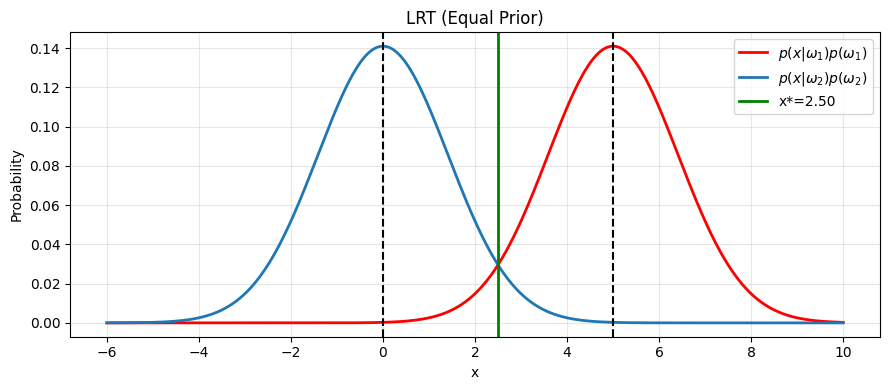

In [348]:
plot_lrt(mu1=5, mu2=0, Var=2, p1=0.5, p2=0.5)

### **3. What happens if Happy Cat Priors Probabilities = 0.8**

Boundary: 1.95


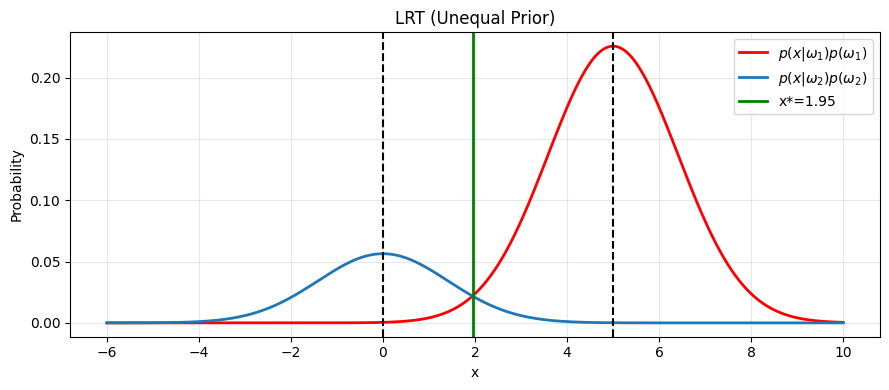

In [349]:
plot_lrt(mu1=5, mu2=0, Var=2, p1=0.8, p2=0.2)

Boundary: 1.95


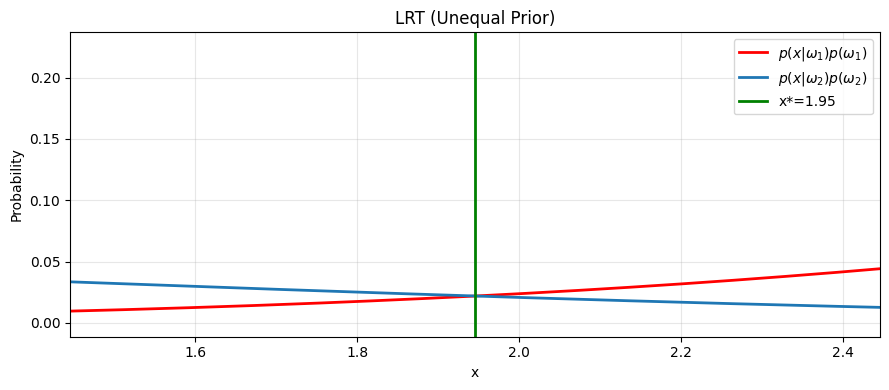

In [350]:
plot_lrt(mu1=5, mu2=0, Var=2, p1=0.8, p2=0.2, zoom=True, zoom_width=0.5)

We apply the LRT with unequal prior probabilities :

$$
\begin{aligned}
P(Happy Cat)=0.8, P(Sad Cat)=0.2
\end{aligned}
$$

The resulting decision boundary is

$$
\begin{aligned}
x^∗=1.95
\end{aligned}
$$

If we zoom in we will see that **the new decision boundary is shifts left** from the equal-prior boundary $x^∗=2.5$ and ***the predicted result is Happy Cat***

**Conclusion :**
1. **The Decision Boundary**: In the equal-prior case, the curves intersect at the midpoint (2.5). With unequal priors, the Happy Cat curve shifts upward and the Sad Cat curve shifts downward, causing the decision boundary to move left.
2. **Effect of Prior**: The prior represents initial belief. Since we assume most cats are Happy, the model requires stronger evidence to classify a cat as Sad (cat ate nearly 0 food). Therefore, the decision region for Happy Cat becomes larger.

---

## **Chapter 02**

In [351]:
import pandas as pd

df = pd.read_csv(r'C:\Users\User\Desktop\FIBO_Study\3Y_2\FRA501_PATTERN\HW02\WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [352]:
print(df.shape)

(1470, 35)


In [353]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [354]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


The Attrition is target, and other features are input.

In [355]:
df.loc[df["Attrition"] == "No",  "Attrition"] = 0.0
df.loc[df["Attrition"] == "Yes", "Attrition"] = 1.0

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    df[col] = pd.Categorical(df[col]).codes

print(df.dtypes)

Age                         int64
Attrition                    int8
BusinessTravel               int8
DailyRate                   int64
Department                   int8
DistanceFromHome            int64
Education                   int64
EducationField               int8
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                       int8
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                      int8
JobSatisfaction             int64
MaritalStatus                int8
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                       int8
OverTime                     int8
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [356]:
df = df.drop(columns="EmployeeNumber")
print(df.shape)

(1470, 34)


In [357]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
print(len(X_train), len(X_test), len(y_train), len(y_test))

1323 147 1323 147


In [358]:
def plot_hist(train_set, features, bin_sizes, y=None, figsize=(12, 4), mode="count"):
    
    for bins in bin_sizes:
        plt.figure(figsize=figsize)
        
        for i, feature in enumerate(features, 1):
            
            plt.subplot(1, len(features), i)
            
            data_all = train_set[feature].dropna().values
            edges = np.linspace(data_all.min(), data_all.max(), bins + 1)
            
            if mode == "count":
                hist, bin_edge = np.histogram(data_all, bins=edges)
                zero_bins = np.sum(hist == 0)
                
                plt.stairs(hist, bin_edge, fill=True)
                plt.ylabel("Count")
                plt.title(f"{feature} ({bins} bins)\nZero bins = {zero_bins}")
            
            elif mode == "likelihood": 
                
                classes = np.unique(y)
                
                for c in classes:
                    data_class = train_set[y == c][feature].dropna().values
                    hist, bin_edge = np.histogram(data_class, bins=edges)
                    likelihood = hist / hist.sum() # p(x | class)
                    
                    plt.stairs(likelihood, bin_edge, fill=True, alpha=0.4, label=f"Attrition = {c}")
            
                plt.ylabel("P(x | class)")
                plt.title(f"{feature} ({bins} bins)")
                plt.legend()
            
            plt.xlabel(feature)
        
        plt.tight_layout()
        plt.show()

In [359]:
features = ["Age", "MonthlyIncome", "DistanceFromHome"]

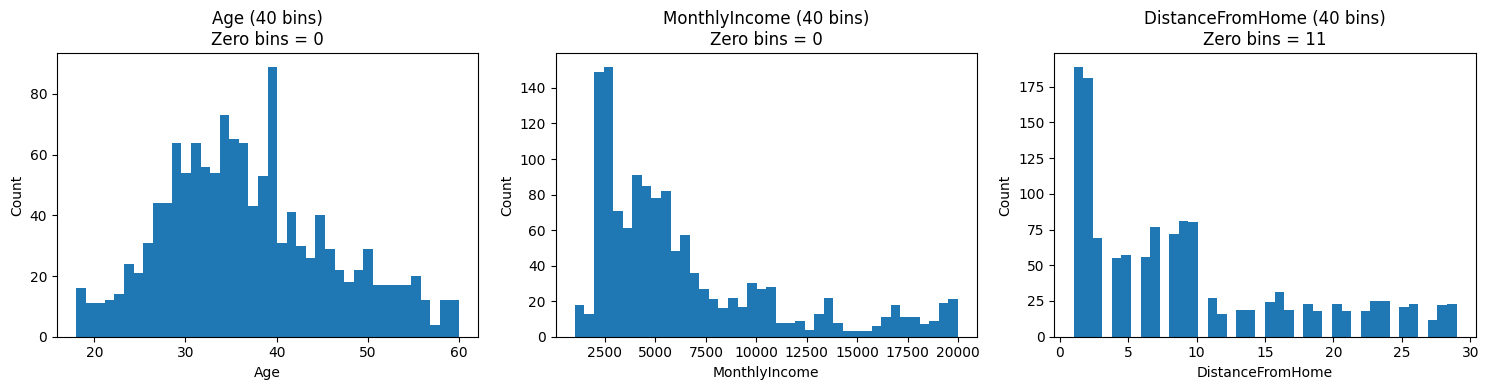

In [360]:
plot_hist(X_train, features, [40], y=y_train, figsize=(15, 4), mode="count")

### **1. How many bins have zero counts? Do you think this is a good discretization? Why?**

From the histograms for each feature in **40 bins** have a **zero count bins for Age, MonthlyIncome, and DistanceFromHome**:
- Age (0)
- MonthlyIncome (0)
- DistanceFromHome (11)

Regarding whether **this is a good discretization**:
- For **Age** and **MonthlyIncome**, the absence of zero-count bins indicates that the 40 bin resolution is suitable for the current sample size. It provides a smooth representation of the distribution without over-segmenting the data.
- For **DistanceFromHome**, the presence of **11 zero-count bins** indicates that 40 bins might be **too many (too fine)** for this feature. This creates gaps in the distribution where no data points exist. To improve this, we could **increase the bin width (reduce the number of bins)** to consolidate the sparse data points, which would help in creating a more continuous and reliable estimate for modeling.


**Key Takeaway:**

It's important to choose a bin size that aligns with the data distribution and avoid **Zero-count bins (Graphical) or Data Sparsity (Statistical)**, as this causes the **Zero Frequency Problem**. Zero-count bins can lead to poor predictions, especially when a feature has sparsity, causing models to assign zero probabilities to unseen data.

### **2. Can we use a Gaussian to estimate this histogram? Why?**

**Not effectively** for this Attrition Problem because a the **data distribution is not Normal** and it is **better to use the histogram Naive Bayes** for the clear classification problem
- **Why not**: It is unsuitable for these 40 bin resolution histograms because they exhibit significant skew and multimodality. For instance:
    - **MonthlyIncome** and **DistanceFromHome** are highly skewed to the right. A standard Gaussian would poorly fit these heavy tails.
    - **Age** and **DistanceFromHome** show several distinct peaks, which a single Gaussian cannot capture.

### **What about a Gaussian Mixture Model (GMM)?**

**Yes, GMM is much better suited for this data.** GMM represents an overall distribution as a weighted combination of multiple Gaussian distributions.
- **Handling Multimodality**: GMM can capture the subpopulations (multiple peaks) within the Age and DistanceFromHome data by assigning a different Gaussian component to each peak.
- **Addressing Sparsity (Zero Bins)**: GMM is a continuous probability model. Unlike a histogram which can have zero count bins due to limited data, GMM estimates an underlying density that provides a non-zero probability even for those empty gaps.

**Conclusion**: GMM is the great choice here because it can smooth the gaps caused by zero-count bins and accurately represent the multiple peaks seen in features like DistanceFromHome.

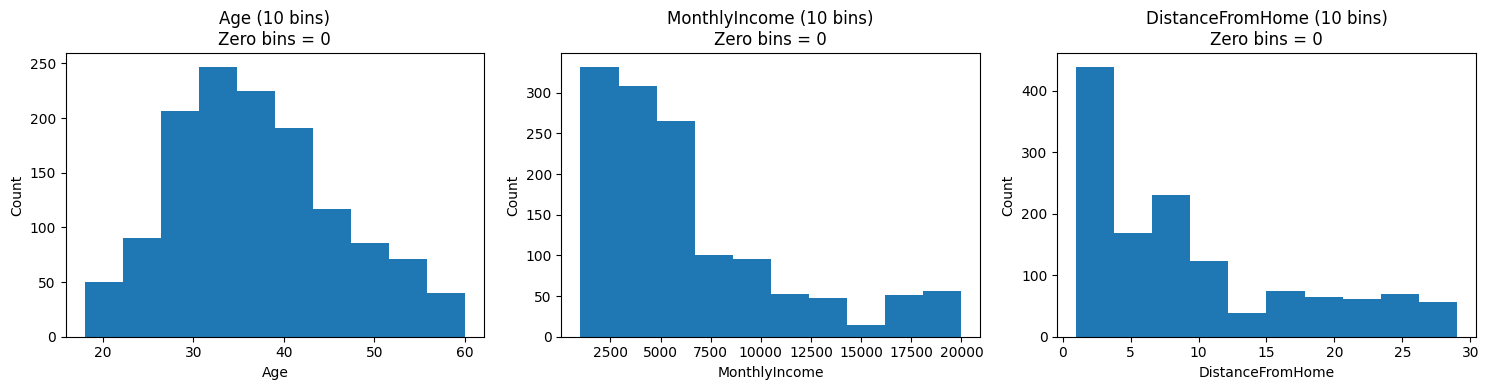

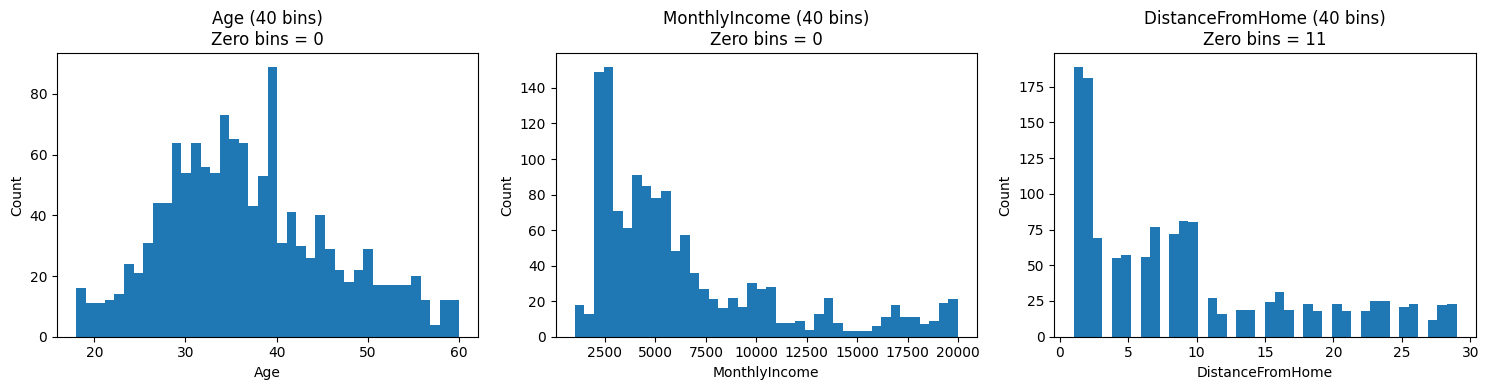

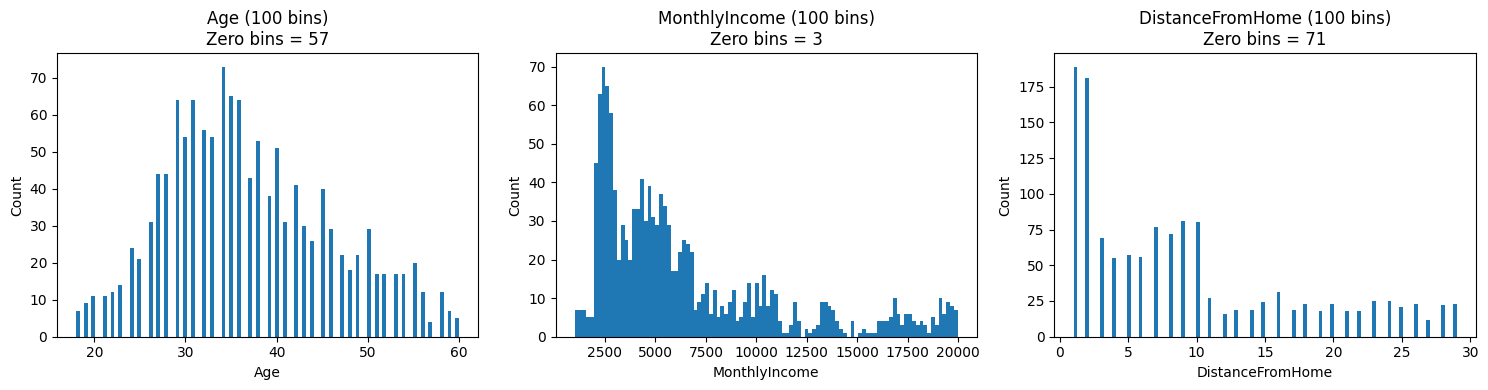

In [361]:
plot_hist(X_train, features, [10, 40, 100], y=y_train, figsize=(15, 4), mode="count")

### **3. Plot the histogram with these values bin size {10, 40, 100}, Which bin size is most sensible for each feature? Why?**

Based on the analysis of the **9 histograms**, here is **the most sensible bin size for each**
1. **Age: 40 bins**
- **Unsuitable**: The **10-bin** version is too coarse and hides the true distribution peaks. However, the **100-bin** version is too fine and cause the **57 zero-count bins**.
- **Suitable**: At **40 bins**, the distribution shape is clear and continuous with **Zero bins = 0**, indicating it effectively captures every age group in the sample without gaps.

2. **MonthlyIncome: 40 bins**
- **Unsuitable**: The **10-bin** version is too coase, while the **100-bin** version becomes too jittery to interpret easily.
- **Suitable**: **40 bins** maintains **Zero bins = 0** while revealing distinct sub-peaks in income levels better than the 10-bin version, offering a more great view of the salary structure.

3. **DistanceFromHome: 10 bins**
- **Unsuitable**: This feature has **high Data Sparsity** at higher values from EDA. Moving to **40 bins immediately creates gaps (11 zero bins)**, and **100 bins** makes the problem severe disconnected.
- **Suitable**: **10 bins** is the most sensible choice because it "consolidates" sparse data points into stable bars. While some detail is lost, it eliminates the **Zero Frequency Problem** and provides a more statistically reliable overview of commuting patterns.

**Key Takeaway:**
We discretized for estimate the $P(x | class)$ which the probability in at single point. Thus, the optimal bin size is a balance between:
1. **Resolution**: High enough to show the **shape** and **peaks** (modes) of the data.
2. **Statistical Reliability**: Low enough to avoid **Zero-count bins**, which ensures the model doesn't assign zero probabilities to realistic values during future predictions.

### **4. Which one should be discretized in order to be modeled by histograms?**

In this IBM Attrition dataset, **Numeric features with wide range** should be discretized, while **Categorical** and **Ordinal** features generally should not.
- **Discretize These (Numeric)**: *TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, DailyRate, HourlyRate, MonthlyRate, and PercentSalaryHike.*
    - **Why**: These have many unique integer values. If modeled raw, many specific values might have zero counts in the training set, triggering the Zero-Frequency Problem during testing.

### **What are the criteria for choosing whether we should discretize a feature or not?**

1. **High Number of Unique**: Discretize numerical features with too many unique values to simplify the model's complexity.
2. **Zero-count bins**: When a histogram shows many empty gaps, grouping them into larger bins prevents the **Zero Frequency Problem.**
3. **Non-linear Relationships**: If the target doesn't change linearly with a feature, binning helps capture specific high-risk ranges.
4. **Outlier Robustness**: Discretizing clusters that have outliers into the final bins, preventing them from skewing the model's overall distribution.
5. **Interpretability**: Transforming raw numbers into meaningful business categories makes findings more actionable.

**Key Takeaways:**
- Balance is Key: Discretization is a trade-off between reducing noise and information loss.
- Model-Specific: Probabilistic models like Naive Bayes often require discretization to calculate probabilities effectively without hitting zero-counts.
- Feature Choice: Only discretize High-range Continuous features (like rates or years); avoid discretizing Ordinal features (like Satisfaction levels) as they are already pre-binned.

### **5. Plot the likelihood distributions of the features from (4) for different Attrition values.**

We selected these 4 features for plot the likelihood distributions :
- **YearsAtCompany**: Very similiar to *TotalWorkingYears, YearsInCurrentRole, YearsWithCurrManager* because they are all measure how long someone has worked but **the select one is directly related to attrition decision.**
- **YearsSinceLastPromotion**: This measures stagnation.
- **MonthlyRate**: These are almost the same type *DailyRate, HourRate*. But the select one using month which I think the best describe period for working at company.
- **PercentSalaryHike**: This represent the satisfaction.

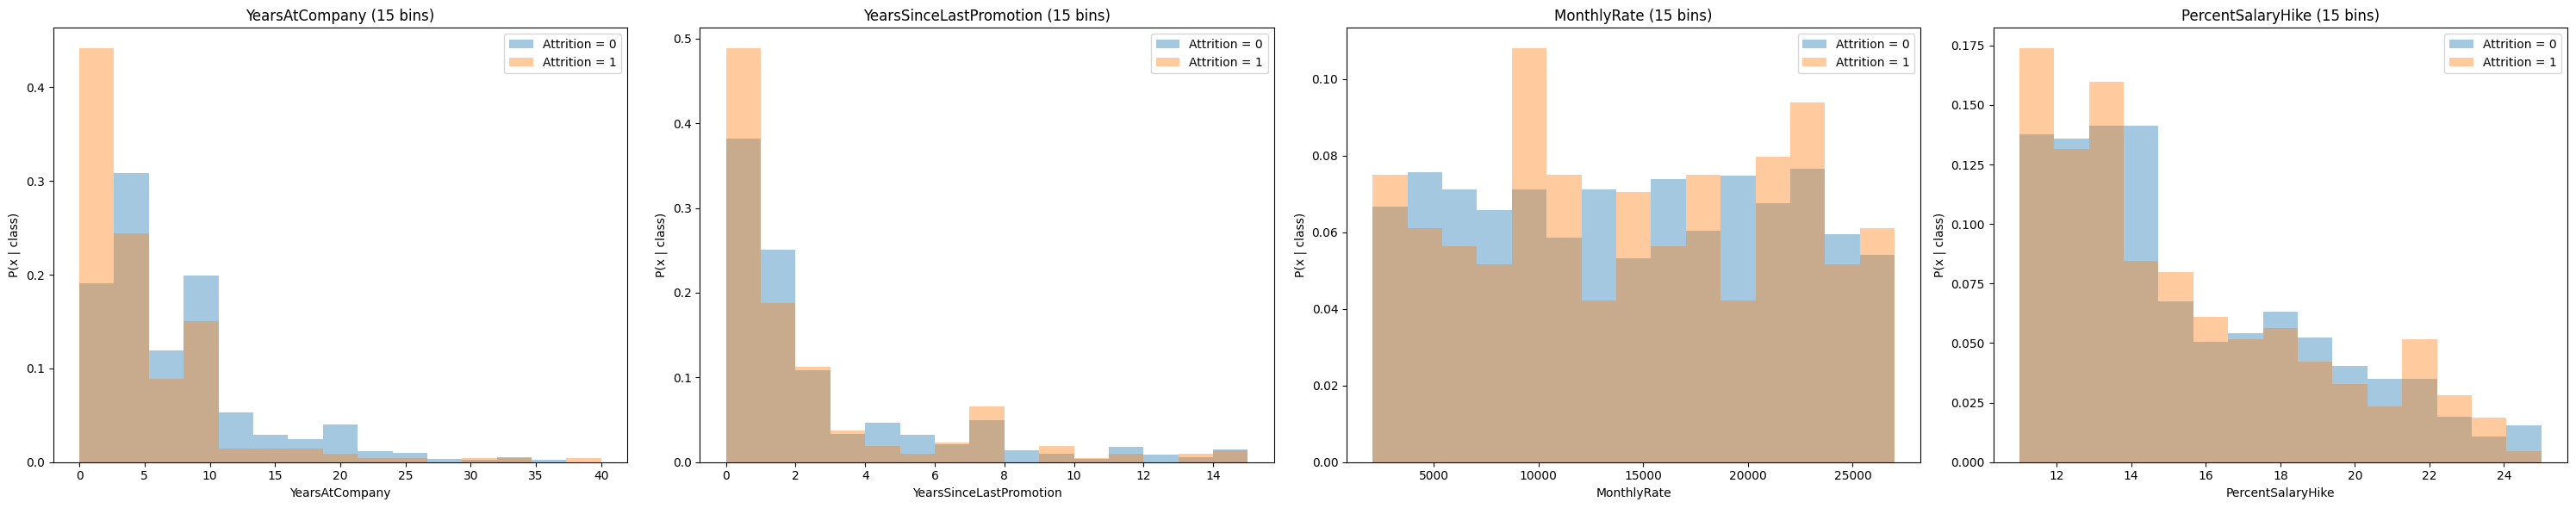

In [362]:
s_features_q5 = ["YearsAtCompany", "YearsSinceLastPromotion", "MonthlyRate", "PercentSalaryHike"]
plot_hist(X_train, s_features_q5, [15], y=y_train, figsize=(30, 6), mode="likelihood")

**Analyze:**

- **Prevent Zero-Frequency Problem**: If the plot have a gaps this mean the some data interval will be 0 values which makes the product in $H(x)$ be 0 as well and the model can not predict.
- **Robustness**: Graph that have no gaps will reduce the noise and represent the clear trend of the data compare to the graph that have a multiple gaps which shown the overfitting.
- **Likelihood Distribution**: Using the suitable bin will makes us see the saperation of Attrition Class = 0, 1 clearly.

### **6. Derive the log-likelihood function of 𝐻(𝑥), and state the decision conditions for the leave and stay classes.**

$$H(x) = \frac{p(\text{leave})}{p(\text{stay})} \prod_{i=1}^{n} \frac{p(x_i|\text{leave})}{p(x_i|\text{stay})}$$

Take the Log on bothside.

$$\ln(H(x)) = \ln\left( \frac{p(\text{leave})}{p(\text{stay})} \prod_{i=1}^{n} \frac{p(x_i|\text{leave})}{p(x_i|\text{stay})} \right)$$

Use the Logarithm property $\ln(ab) = \ln a + \ln b$ and $\ln(\frac{a}{b}) = \ln a - \ln b$ :

$$\ln(H(x)) = \ln(p(\text{leave})) - \ln(p(\text{stay})) + \sum_{i=1}^{n} \left[ \ln(p(x_i|\text{leave})) - \ln(p(x_i|\text{stay})) \right]$$

**Decision conditions** :
when we use Log the decision from $H(x) = 1$ will change $\ln(1) = 0$:
- **Leave** : When $\ln(H(x)) > 0$
- **Stay** : When $\ln(H(x)) < 0$

### **7. Method to fix the Zero-Frequency Problem**

**Problem:** If even a single value of $p(x_i|\text{attrition})$ is zero, the entire product term will immediately become zero. In a log scale, this results in a value of $-\infty$, making the model unable to calculate or compare values effectively.

**Solution:** Use **Laplace Smoothing**

**Method:** This involves adding a small constant (typically $\alpha = 1$) to the numerator and adding the total number of possible categories (bins) to the denominator as follows:

$$P(x_i|c) = \frac{\text{count}(x_i, c) + \alpha}{\text{count}(c) + \alpha \cdot d}$$

- $\text{count}(x_i, c)$: The number of times feature $x_i$ appears in class $c$.
- $\text{count}(c)$: The total number of all samples in class $c$.
- $\alpha$: The smoothing parameter (commonly set to 1).
- $d$: The number of bins or the total number of possible unique values for that feature.

**Reasoning:** This method guarantees that the probability value will always be positive (greater than 0). Consequently, calculations in the log scale will not encounter errors, and the model becomes more robust and flexible when encountering data that was not present during the training phase.

### **8. Implementation of Naive Bayes Classifier from Histogram Discretization**

In [363]:
class DiscreteNaiveBayes:
    
    def __init__(self, bins=20):
        self.bins = bins

    def fit(self, X_train, y_train):
        
        self.classes = np.unique(y_train)
        self.priors = {}
        self.hist_data = {}
        
        for c in self.classes:
        
            X_c = X_train[y_train == c]
            
            self.priors[c] = len(X_c) / len(X_train) # compute prior
            self.hist_data[c] = {}
            
            for feature in X_train.columns:
                
                edges = np.linspace(X_train[feature].min(),X_train[feature].max(),self.bins + 1)
                values = X_c[feature].dropna().values
                hist, _ = np.histogram(values, bins=edges)
                hist = hist + 1  # Laplace smoothing
                prob = hist / hist.sum() 
                
                self.hist_data[c][feature] = (prob, edges)
    
    
    def predict(self, X_test):
        
        predictions = []
        
        for _, row in X_test.iterrows():
            class_scores = []
            
            for c in self.classes:
                score = np.log(self.priors[c])  # start with log prior
                
                for feature in X_test.columns:
                    value = row[feature]
                    if pd.isna(value): # Handle missing values by skipping
                        continue
                    prob, edges = self.hist_data[c][feature]
                    bin_index = np.digitize(value, edges) - 1  # find which bin this value belongs to
                    
                    if 0 <= bin_index < len(prob):
                        score += np.log(prob[bin_index])
                    else:
                        score += np.log(1e-12)
                
                class_scores.append(score)
            predictions.append(self.classes[np.argmax(class_scores)])
        return np.array(predictions)

Approximates distribution using histogram bin probabilities $P(x|c) = \frac{\text{count in bin}}{\text{total count}}$

In [364]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train, y_train, X_test, y_test, positive_class=1):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, pos_label=positive_class)
    recall = recall_score(y_test, pred, pos_label=positive_class)
    f1 = f1_score(y_test, pred, pos_label=positive_class)
    
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

In [365]:
dnb = DiscreteNaiveBayes(bins=40)
evaluate_model(dnb, X_train, y_train, X_test, y_test)

Accuracy : 0.8163265306122449
Precision: 0.2857142857142857
Recall   : 0.08333333333333333
F1 Score : 0.12903225806451613


### **9. Implementation of Guassian Naive Bayes Classifier**

In [366]:
from scipy.stats import norm

class NaiveBayes:
    
    def __init__(self, bins=40):
        self.bins = bins
    
    def fit(self, X_train, y_train):
        self.classes = np.unique(y_train)
        self.priors = [len(y_train[y_train == c]) / len(y_train) for c in self.classes]
        self.means = [X_train[y_train == c].mean() for c in self.classes]
        self.stds = [X_train[y_train == c].std() for c in self.classes]
    
    def predict(self, X_test):
        y_pred = []
        
        for _, row in X_test.iterrows():
            log_posteriors = []
            
            for i in range(len(self.classes)):
                
                log_prior = np.log(self.priors[i])
                log_likelihood = 0
                
                for feature in row.index:
                    value = row[feature]
                    mean = self.means[i][feature]
                    std = self.stds[i][feature]
            
                    if std == 0:
                        std = 1e-6
                
                    pdf = norm(mean, std).pdf(value)
                    log_likelihood += np.log(pdf + 1e-12) # add small value to prevent log(0)
                
                log_posteriors.append(log_prior + log_likelihood)
            y_pred.append(self.classes[np.argmax(log_posteriors)])
        return np.array(y_pred)

Assumes Normal distribution $\frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

In [367]:
gnb = NaiveBayes(bins=40)
evaluate_model(gnb, X_train, y_train, X_test, y_test)

Accuracy : 0.7142857142857143
Precision: 0.32
Recall   : 0.6666666666666666
F1 Score : 0.43243243243243246


**Conclusion:** Although the Discrete Naive Bayes model achieved **higher overall accuracy**,** it performed **poorly in detecting attrition cases**, as indicated by very **low recall and F1 score**. This suggests that the model is biased toward the majority class. In contrast, the **Gaussian Naive Bayes model** achieved significantly **higher recall and F1 score**, making it more suitable for attrition prediction despite its lower overall accuracy.